In [6]:
import pandas as pd
import json
from pathlib import Path


district_nums = [(8,5), (10,4), (16,5), (20,4), (40,1), (80,1)]
district_mode = ["cambridge", "slate_pl", "slate_bt"]
parties = ["D", "R"]
party_focal = parties[0]
races = ["H", "O"]
race_focal = races[0]
plans = ["000", "200", "400", "600", "800"]
num_profiles_per_district = 100 ### CHANGE

# Might need to run vk_settings_generator again

## Extract results for race

In [ ]:
def avg_prop(dist_res, num_profiles, seats, focal):
    all_entries = [item for unit in dist_res for item in unit]
    # Count how many belong in focal group
    count = sum(1 for item in all_entries if item.startswith(focal))
        
    # Divide by number of profile reps
    prop = count / (num_profiles*seats)
    return(prop)


In [ ]:
rows = []

# For each district division x seats per district
for (dn, eln) in district_nums:

    # For each mode
    for dm in district_mode:
        results_file=Path(f"./vk_ca_election_model_results_racial/{dm}/ca_{dn}_districts_{eln}_winners_for_voter_model_{dm}.json")

        # For each results file, first divide into results from dn different plans
        # Within each plan, each district was repeated by num_profiles_per_district=100
        # Currently assuming order of result file is (plan1,district1)*100, (plan1, district2)*100, ...(plan2, district1)*100

        with open(results_file, "r") as f:
            data = json.load(f)
            plan_data_len = len(data) // len(plans)

            # First split each result file into results from eachp plan
            results_by_plan = [data[i*plan_data_len:(i+1)*plan_data_len] for i in range(len(plans))]

            # For each grouped results by plan
            for pn in range(len(results_by_plan)):
                res_plan = results_by_plan[pn]

                # Split into grouped results by district. Each district should have reps of num_profiles_per_district=100
                results_by_district = [res_plan[i:i+num_profiles_per_district] for i in range(0, len(res_plan), num_profiles_per_district)]

                # For each district
                for dist_id in range(len(results_by_district)):
                    res_dist = results_by_district[dist_id]

                    # Calculate average proportion across vk election results
                    pr = avg_prop(res_dist, num_profiles_per_district, eln, race_focal)

                    # Add census demographic info from settings file
                    settings_folder = Path(f"./vk_run_settings_racial_turnout/{dn}")
                    settings_filename = f"ca_{dn}_vk_sample_settings_district_plan_{plans[pn]}_district_{dist_id:02d}.json"
                    settings_filepath = settings_folder / settings_filename

                    with open(settings_filepath, "r") as g:
                        settings_data = json.load(g)
                        total_hvap = settings_data.get("total_hvap", None)
                        total_vap = settings_data.get("total_vap", None)                        
                        rows.append({"plan": plans[pn],
                                    "total_district_num": dn,
                                    "total_elected": eln,
                                    "dist_num": dist_id,
                                    "mode": dm,
                                    "H_vk_avg_prop": pr,
                                    "H_prop_census": total_hvap/total_vap})

df = pd.DataFrame(rows)
df.head()

In [ ]:
df.to_csv("Racial_results.csv", index=False) 


## Extract results for partisanship

In [ ]:
partisan_rows = []

# For each district division x seats per district
for (dn, eln) in district_nums:

    # For each mode
    for dm in district_mode:
        results_file=Path(f"./vk_ca_election_model_results_partisan_debug/{dm}/ca_{dn}_districts_{eln}_partisan_winners_for_voter_model_{dm}.json")

        # For each results file, first divide into results from dn different plans
        # Within each plan, each district was repeated by num_profiles_per_district=100
        # Currently assuming order of result file is (plan1,district1)*100, (plan1, district2)*100, ...(plan2, district1)*100

        with open(results_file, "r") as f:
            raw_data = json.load(f)
            data = raw_data#[-dn*eln*num_profiles_per_district:]
            plan_data_len = len(data) // len(plans)

            # First split each result file into results from each plan
            results_by_plan = [data[i*plan_data_len:(i+1)*plan_data_len] for i in range(len(plans))]

            # For each grouped results by plan
            for pn in range(len(results_by_plan)):
                res_plan = results_by_plan[pn]

                # Split into grouped results by district. Each district should have reps of num_profiles_per_district=100
                results_by_district = [res_plan[i:i+num_profiles_per_district] for i in range(0, len(res_plan), num_profiles_per_district)]

                # For each district
                for dist_id in range(len(results_by_district)):
                    res_dist = results_by_district[dist_id]

                    # Calculate average proportion across vk election results
                    pr = avg_prop(res_dist, num_profiles_per_district, eln, party_focal)

                    # Add census demographic info from settings file
                    settings_folder = Path(f"./vk_run_settings_partisan/{dn}")
                    settings_filename = f"ca_{dn}_vk_sample_settings_partisan_district_plan_{plans[pn]}_district_{dist_id:02d}.json"
                    settings_filepath = settings_folder / settings_filename

                    with open(settings_filepath, "r") as g:
                        settings_data = json.load(g)
                        bloc_pr = settings_data.get("bloc_proportions", None)

                        partisan_rows.append({"plan": plans[pn],
                                    "total_district_num": dn,
                                    "total_elected": eln,
                                    "dist_num": dist_id,
                                    "mode": dm,
                                    "Dem_vk_avg_prop": pr,
                                    "Dem_prop_census": bloc_pr["D"]/(bloc_pr["D"]+bloc_pr["R"])})

partisan_df = pd.DataFrame(partisan_rows)
partisan_df.head()

In [ ]:
partisan_df.to_csv("Partisan_results.csv", index=False) 

## Histograms of Hispanic seat count for each district x seat configuration

In [7]:
def count_focal_winners(rep_res, focal):
    # Count how many belong in focal group
    all_entries = [item for unit in rep_res for item in unit]
    count = sum(1 for item in all_entries if item.startswith(focal))
    return(count)

In [ ]:
rows = []

# For each district division x seats per district
for (dn, eln) in district_nums:

    # For each mode
    for dm in district_mode:
        results_file=Path(f"./vk_ca_election_model_results_racial_turnout/{dm}/ca_{dn}_districts_{eln}_winners_for_voter_model_{dm}.json")

        # For each results file, first divide into results from dn different plans
        # Within each plan, each district was repeated by num_profiles_per_district=100
        # Currently assuming order of result file is (plan1,district1)*100, (plan1, district2)*100, ...(plan2, district1)*100

        with open(results_file, "r") as f:
            data = json.load(f)
            plan_data_len = len(data) // len(plans)

            # First split each result file into results from eachp plan
            results_by_plan = [data[i*plan_data_len:(i+1)*plan_data_len] for i in range(len(plans))]

            # For each grouped results by plan
            for pn in range(len(results_by_plan)):
                res_plan = results_by_plan[pn]

                # Split into grouped results by district. Each district should have reps of num_profiles_per_district=100
                results_by_district = [res_plan[i:i+num_profiles_per_district] for i in range(0, len(res_plan), num_profiles_per_district)]
                # For each district
                for dist_id in range(len(results_by_district)):
                    res_dist = results_by_district[dist_id]

                    # For each rep
                    for rep_n in range(len(res_dist)):
                        # Result per rep
                        rep_res = res_dist[rep_n]
                        # Calculate average proportion across vk election results
                        rep_count = count_focal_winners(rep_res, race_focal)
                        
                        # Add census demographic info from settings file
                        settings_folder = Path(f"./vk_run_settings_racial_turnout/{dn}")
                        settings_filename = f"ca_{dn}_vk_sample_settings_district_plan_{plans[pn]}_district_{dist_id:02d}.json"
                        settings_filepath = settings_folder / settings_filename

                        with open(settings_filepath, "r") as g:
                            settings_data = json.load(g)
                            total_hvap = settings_data.get("total_hvap", None)
                            total_vap = settings_data.get("total_vap", None)                        
                            rows.append({"plan": plans[pn],
                                        "total_district_num": dn,
                                        "seats_per_district": eln,
                                        "dist_num": dist_id,
                                        "mode": dm,
                                        "vap": total_vap,
                                        "hvap": total_hvap,
                                        "rep": rep_n,
                                        "H_seats": rep_count})

df_hist = pd.DataFrame(rows)
# df_hist.head()

,plan,total_district_num,seats_per_district,dist_num,mode,vap,hvap,rep,H_seats
0,000,8,5,0,cambridge,3689662.0,1821400.0,0,1
1,000,8,5,0,cambridge,3689662.0,1821400.0,1,1
2,000,8,5,0,cambridge,3689662.0,1821400.0,2,2
3,000,8,5,0,cambridge,3689662.0,1821400.0,3,2
4,000,8,5,0,cambridge,3689662.0,1821400.0,4,2


In [ ]:
# Histograms for seat frequency per config

import matplotlib.pyplot as plt

dist_seats = {8:5, 10:4, 16:5, 20:4, 40:1, 80:1}

for dn, group in df_hist.groupby("total_district_num"):
    plt.figure(figsize=(6,4))
    plt.hist(group["H_seats"], bins=range(group["H_seats"].min(), group["H_seats"].max()+2), 
             align='left', edgecolor='gray', color='skyblue')
    plt.xticks(range(group["H_seats"].min(), group["H_seats"].max()+1))
    plt.xlabel("Seats for Focal Race")
    plt.ylabel("Frequency")
    plt.title(f"Hispanic seats from {dn} district x {dist_seats[dn]} seat plans")
    plt.show()

In [ ]:
## Compute HVAP proportion


## Draw histogram of seat count for each run

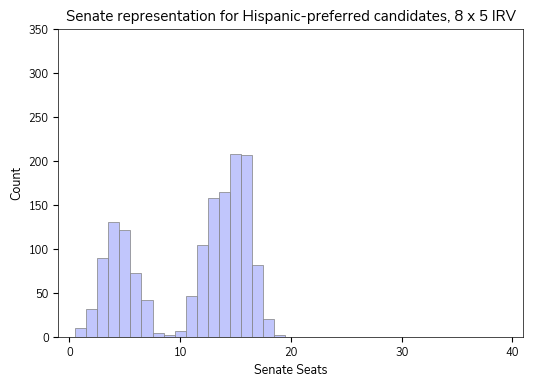

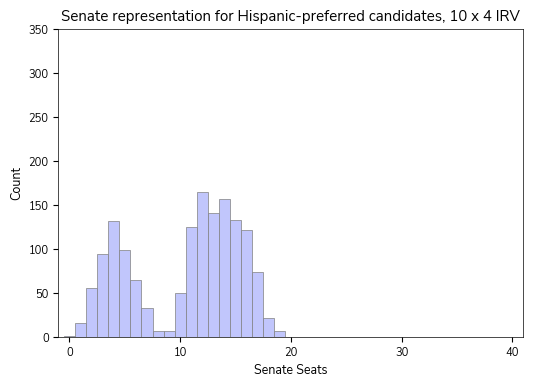

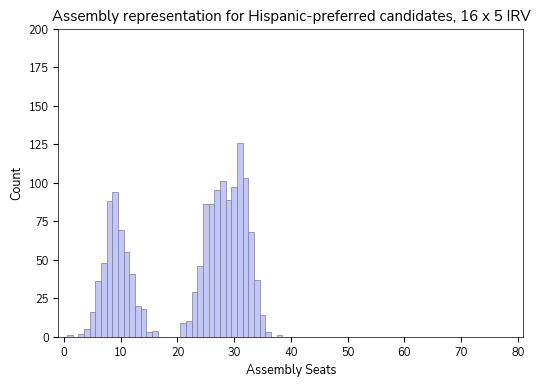

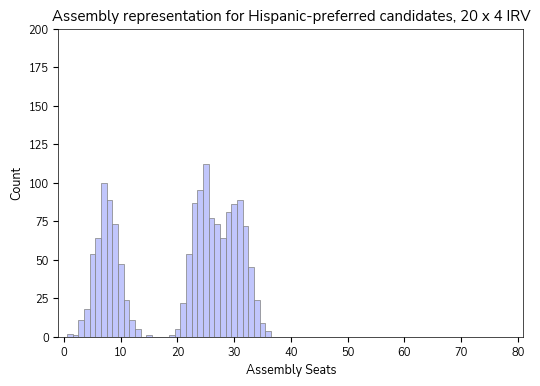

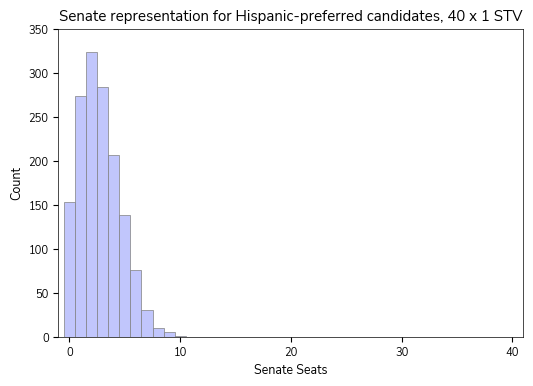

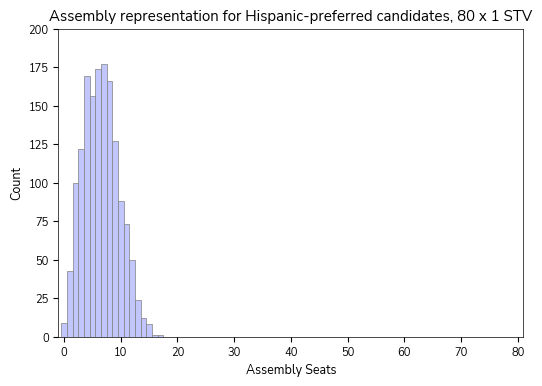

In [53]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Nunito Sans']

agg = (df_hist.groupby(["plan", "total_district_num", "mode", "rep"], as_index=False)
      .agg({"H_seats": "sum"}))


dist_seats = {8:5, 10:4, 16:5, 20:4, 40:1, 80:1}

# colors to try: soft pink, apricot
for dn, group in agg.groupby("total_district_num"): 
    plt.rc('font', size=9)   
    fig, ax = plt.subplots(figsize=(6,4))  # create a figure + axes
    
    ax.hist(
        group["H_seats"],
        bins=range(group["H_seats"].min(), group["H_seats"].max() + 2),
        align='left',
        edgecolor='gray',
        linewidth = 0.5,
        color='xkcd:light periwinkle'
    )

    # Reduce the weight of the spines (plot boundary)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    
    sen_assem = "Senate" if dn*dist_seats[dn] == 40 else "Assembly"
    election = "STV" if dist_seats[dn]==1 else "IRV"
    ylim = 350 if sen_assem == "Senate" else 200


    ax.set_xlim(-1, dn * dist_seats[dn] + 1)
    ax.set_ylim(0, ylim)
    ax.set_xticks(range(0, dn * dist_seats[dn] + 1, 10))
    ax.set_xlabel(f"{sen_assem} Seats")
    ax.set_ylabel("Count")
    ax.set_title(f"{sen_assem} representation for Hispanic-preferred candidates, {dn} x {dist_seats[dn]} {election}")

    ax.tick_params(axis='both', which='major', labelsize=8)
    plt.savefig(f"figures/hispanic seats {dn} x {dist_seats[dn]}.png", dpi=300, bbox_inches='tight') 

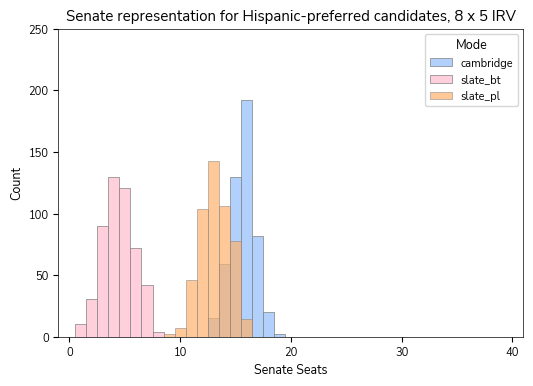

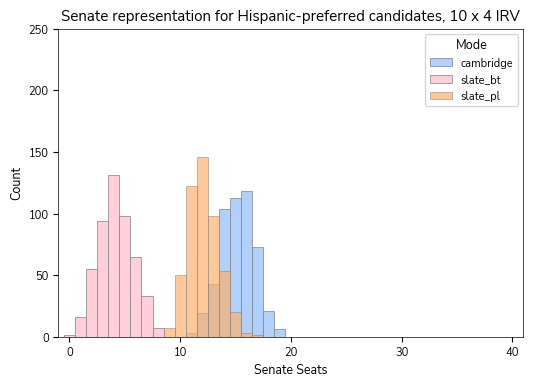

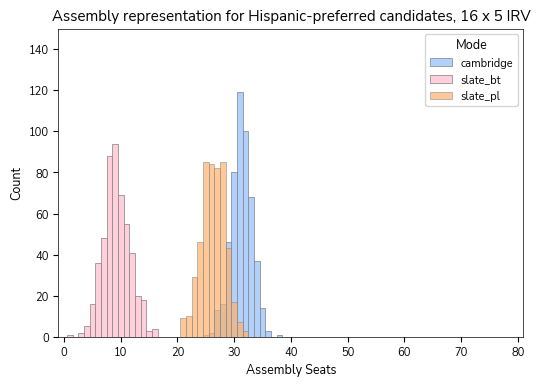

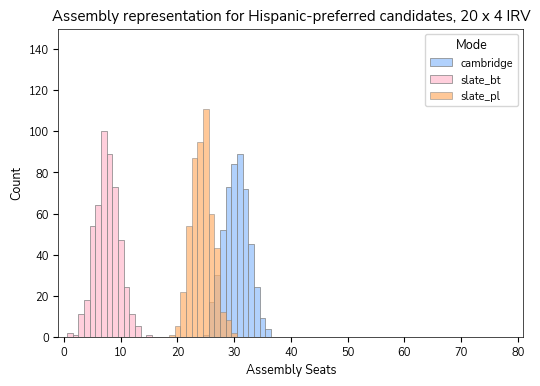

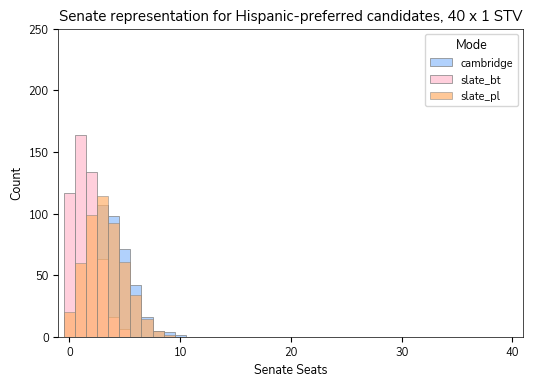

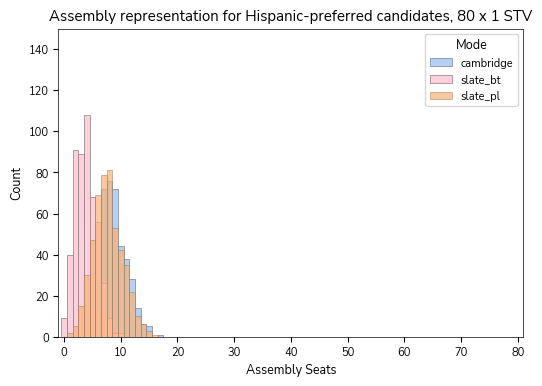

In [47]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Nunito Sans']

agg = (df_hist.groupby(["plan", "total_district_num", "mode", "rep"], as_index=False)
      .agg({"H_seats": "sum"}))

dist_seats = {8:5, 10:4, 16:5, 20:4, 40:1, 80:1}

# Define colors for each mode
mode_colors = {
    "cambridge": "xkcd:powder blue",
    "slate_bt": "xkcd:pale pink",
    "slate_pl": "xkcd:apricot"
}

for dn, group_dn in agg.groupby("total_district_num"): 
    plt.rc('font', size=9)   
    fig, ax = plt.subplots(figsize=(6,4))  # create a figure + axes

    # Plot histogram for each mode
    for mode, group_mode in group_dn.groupby("mode"):
        alpha_val = 0.7 if mode_colors.get(mode) == "xkcd:apricot" else 1.0
        ax.hist(
            group_mode["H_seats"],
            bins=range(group_mode["H_seats"].min(), group_mode["H_seats"].max() + 2),
            align='left',
            edgecolor='gray',
            linewidth=0.5,
            color=mode_colors.get(mode, "xkcd:light gray"),
            alpha=alpha_val,
            label=mode  # add label for legend
        )

    # Reduce the weight of the spines (plot boundary)
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    sen_assem = "Senate" if dn*dist_seats[dn] == 40 else "Assembly"
    election = "STV" if dist_seats[dn]==1 else "IRV"
    ylim = 250 if sen_assem == "Senate" else 150

    # set x-axis limits on the Axes
    ax.set_xlim(-1, dn * dist_seats[dn] + 1)
    ax.set_ylim(0, ylim)
    ax.set_xticks(range(0, dn * dist_seats[dn] + 1, 10))
    ax.set_xlabel(f"{sen_assem} Seats")
    ax.set_ylabel("Count")
    ax.set_title(f"{sen_assem} representation for Hispanic-preferred candidates, {dn} x {dist_seats[dn]} {election}")

    # Add legend for modes
    ax.legend(title="Mode", fontsize=8)

    ax.tick_params(axis='both', which='major', labelsize=8)

    # Save figure
    plt.savefig(f"figures/hispanic_seats_{dn}x{dist_seats[dn]}_bymode.png", dpi=300, bbox_inches='tight')


### Import Nunito Font

In [ ]:
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os


url = "https://raw.githubusercontent.com/googlefonts/NunitoSans/main/fonts/ttf/NunitoSans-Regular.ttf"
font_path = "NunitoSans-Regular.ttf"
font_family = 'Nunito Sans' # Matplotlib needs the exact font name

try:
    print(f"Downloading font from: {url}")
    urllib.request.urlretrieve(url, font_path)
    print("Download complete.")

    file_size = os.path.getsize(font_path)
    print("Font file size (bytes):", file_size)
    
    # A true .ttf file should be much larger than the 191088 bytes of the HTML page
    if file_size < 200000: # Adjusting the check since the HTML was 191088 bytes
        # Optionally, you can perform a better check by inspecting the first few bytes for a 'TTF' header,
        # but a file size check is often sufficient.
        print("⚠️ Warning: Downloaded file size is suspiciously small. It might still be an HTML page.")
    
    # Register in Matplotlib
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = font_family

    # Quick test plot
    plt.figure()
    plt.title(f"Plot with {font_family}", fontsize=16)
    plt.xlabel("X axis label")
    plt.ylabel("Y axis label")
    plt.plot([1, 2, 3], [4, 1, 3])
    plt.grid(True)
    plt.show()
    
except Exception as e:
    print(f"An error occurred: {e}")
    print("Check the URL again or ensure Matplotlib is correctly installed with FreeType support.")
